In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

audio_dir = "C:/Users/zhaoh/Desktop/processed_train/audio"
metadata_file = "C:/Users/zhaoh/Desktop/processed_train/metadata_extracted.csv"

metadata = pd.read_csv(metadata_file)

metadata.head()
metadata.info()
metadata.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   video_id     9989 non-null   object
 1   frames_path  9989 non-null   object
 2   audio_path   9988 non-null   object
 3   utterance    9989 non-null   object
 4   speaker      9989 non-null   object
 5   emotion      9989 non-null   object
 6   sentiment    9989 non-null   object
 7   status       9989 non-null   object
dtypes: object(8)
memory usage: 624.4+ KB


,video_id,frames_path,audio_path,utterance,speaker,emotion,sentiment,status
count,9989,9989,9988,9989,9989,9989,9989,9989
unique,9989,9989,9988,8930,260,7,3,1
top,dia1038_utt17,C:/Users/zhaoh/Desktop/processed_train/frames_...,C:/Users/zhaoh/Desktop/processed_train/audio/d...,Hey!,Joey,neutral,neutral,ok
freq,1,1,1,79,1509,4710,4710,9989


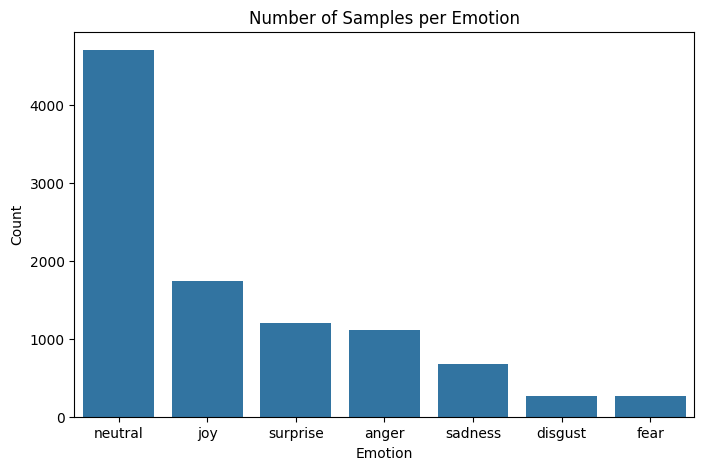

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(data=metadata, x='emotion', order=metadata['emotion'].value_counts().index)
plt.title("Number of Samples per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [4]:
wav_dir = "C:/Users/zhaoh/Desktop/processed_train/audio/"

# List all wav files
wav_files = [f for f in os.listdir(wav_dir) if f.endswith('.wav')]

durations = []

for f in wav_files:
    file_path = os.path.join(wav_dir, f)
    y, sr = librosa.load(file_path, sr=None)
    durations.append(len(y) / sr)

num_files = len(wav_files)
avg_duration = np.mean(durations)
min_duration = np.min(durations)
max_duration = np.max(durations)

print(f"Number of Files: {num_files}")
print(f"Average Duration: {avg_duration:.2f}s")
print(f"Min Duration: {min_duration:.2f}s, Max Duration: {max_duration:.2f}s")

c:\Users\zhaoh\Desktop\CDS\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of Files: 6681
Average Duration: 3.13s
Min Duration: 0.06s, Max Duration: 41.05s


In [5]:
nan_rows = metadata[metadata['audio_path'].isna()]
print(nan_rows)

         video_id                                        frames_path  \
1165  dia125_utt3  C:/Users/zhaoh/Desktop/processed_train/frames_...   

     audio_path                                          utterance speaker  \
1165        NaN  Oh, no-no-no, see, that-that clocks a little ...    Ross   

      emotion sentiment status  
1165  neutral   neutral     ok  


In [6]:
def resolve_path(path):
    if os.path.exists(path):
        return path
    
    alt_path = path.replace("processed_train", "processed_test")
    if os.path.exists(alt_path):
        return alt_path
    
    return None

In [7]:
sample_files = []

for emo, group in metadata.groupby('emotion'):
    valid_path = None
    
    for path in group['audio_path']:
        # Skip if path is NaN or not a string
        if not isinstance(path, str):
            continue
        
        resolved = resolve_path(path)
        if resolved is not None:
            valid_path = resolved
            # break  # you can remove break if you want all valid files
    
    if valid_path is not None:
        sample_files.append((emo, valid_path))
    else:
        print(f"No valid file found for emotion: {emo}")

defaultdict(<class 'list'>, {'anger': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1036_utt15.wav'], 'disgust': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1038_utt12.wav'], 'fear': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1025_utt11.wav'], 'joy': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1038_utt17.wav'], 'neutral': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1038_utt16.wav'], 'sadness': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1036_utt20.wav'], 'surprise': ['C:/Users/zhaoh/Desktop/processed_train/audio/dia1038_utt15.wav']})


C:\Users\zhaoh\AppData\Local\Temp\ipykernel_18776\1065518018.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


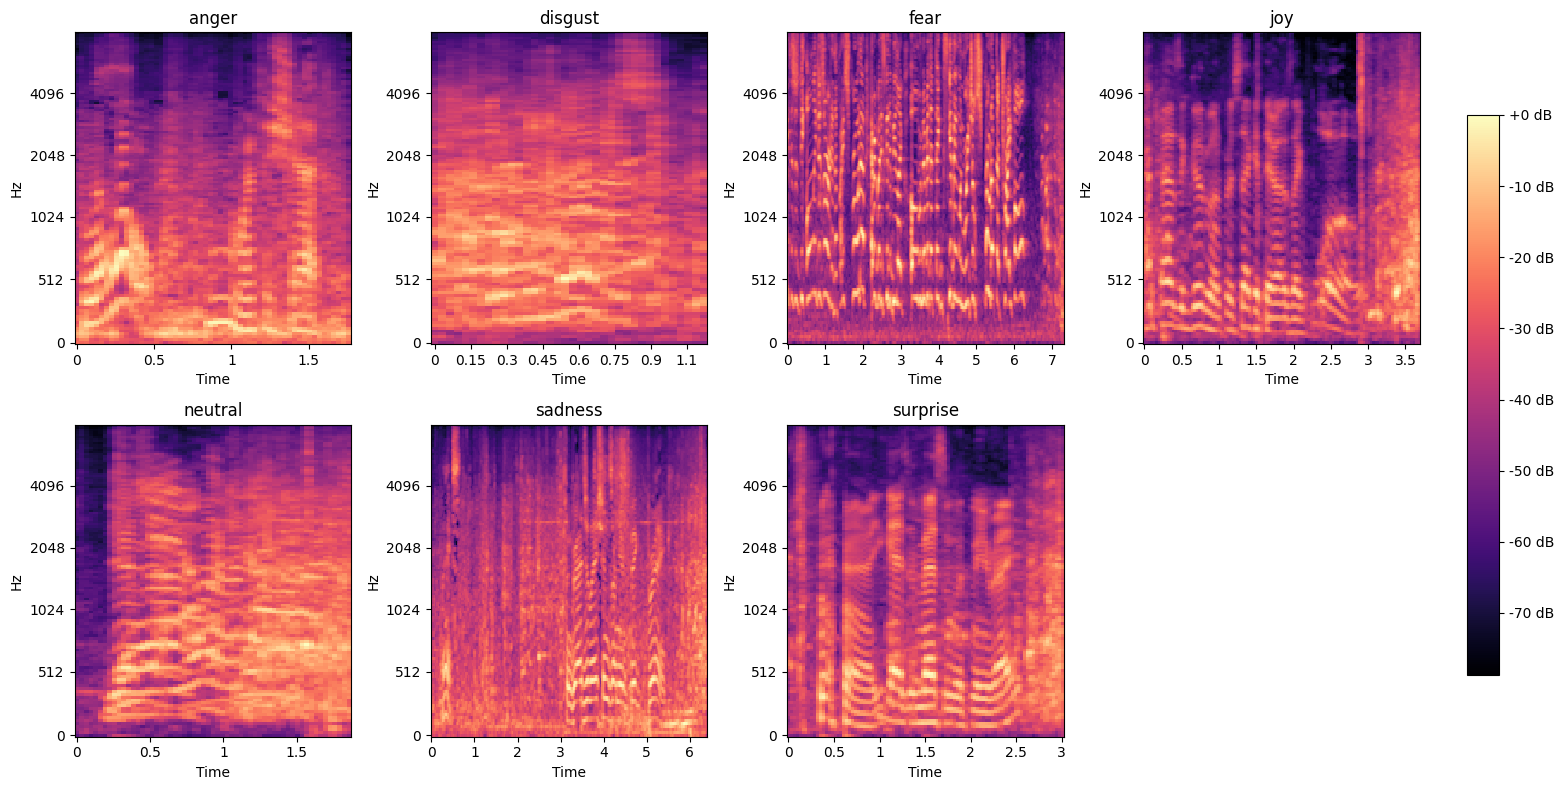

In [8]:
from collections import defaultdict
import math

# Group audio files by emotion
emo_dict = defaultdict(list)
for emo, audio_path in sample_files:
    emo_dict[emo].append(audio_path)
print(emo_dict)
emotions = list(emo_dict.keys())
cols = 4
rows = math.ceil(len(emotions) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for i, emo in enumerate(emotions):
    # Initialize sum for Mel spectrograms
    mel_sum = None
    count = 0
    
    for audio_path in emo_dict[emo]:
        y, sr = librosa.load(audio_path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        if mel_sum is None:
            mel_sum = np.zeros_like(S)
        # If lengths differ, pad or trim to match
        if S.shape[1] < mel_sum.shape[1]:
            S = np.pad(S, ((0,0),(0, mel_sum.shape[1]-S.shape[1])), mode='constant')
        elif S.shape[1] > mel_sum.shape[1]:
            mel_sum = np.pad(mel_sum, ((0,0),(0, S.shape[1]-mel_sum.shape[1])), mode='constant')
        mel_sum += S
        count += 1
    
    # Average Mel spectrogram
    mel_avg = mel_sum / count
    S_dB = librosa.power_to_db(mel_avg, ref=np.max)
    
    img = librosa.display.specshow(
        S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[i]
    )
    axes[i].set_title(emo)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(img, cax=cbar_ax, format='%+2.0f dB')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

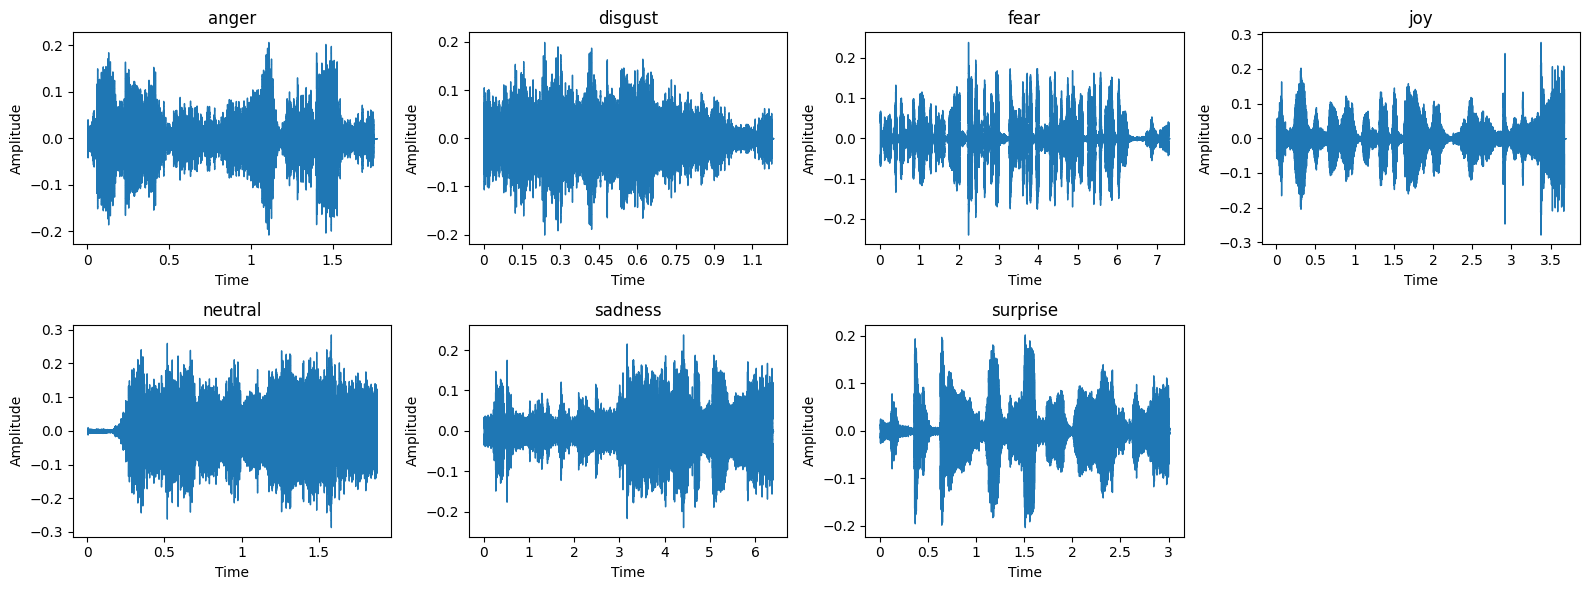

In [9]:
import math

n = len(sample_files)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = axes.flatten()

for i, (emo, audio_path) in enumerate(sample_files):
    y, sr = librosa.load(audio_path, sr=None)
    
    librosa.display.waveshow(y, sr=sr, ax=axes[i])
    axes[i].set_title(emo)
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Amplitude")

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\zhaoh\AppData\Local\Temp\ipykernel_18776\3407997164.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


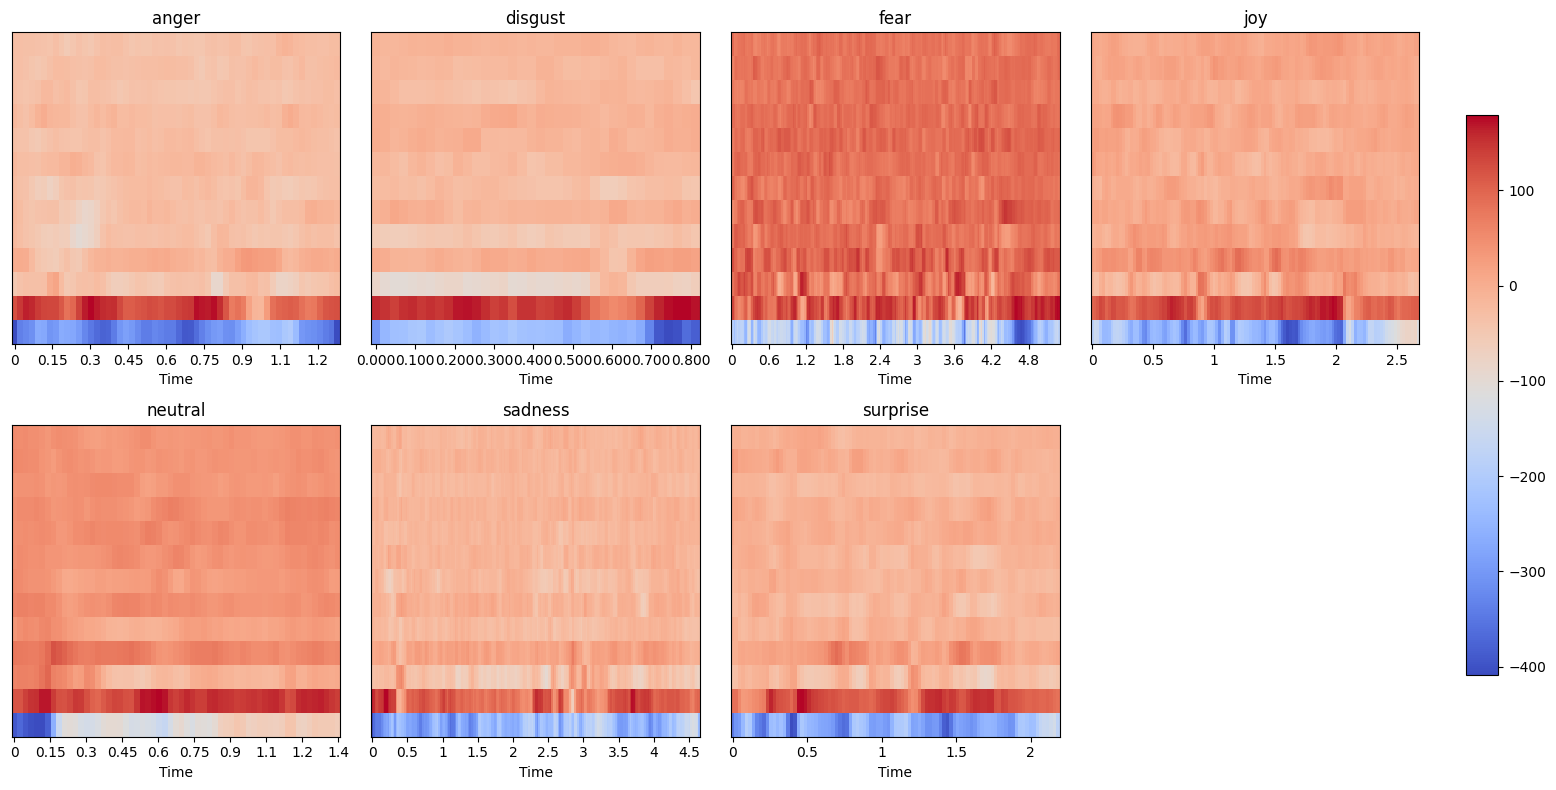

In [10]:
n = len(sample_files)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for i, (emo, audio_path) in enumerate(sample_files):
    y, sr = librosa.load(audio_path, sr=None)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    img = librosa.display.specshow(mfccs, x_axis='time', ax=axes[i])
    axes[i].set_title(emo)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ✅ Add shared colorbar outside
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(img, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()